# Stage 6: Prior-Knowledge Embedding Construction

## Stage Objective

Construct four complementary gene-level representations for co-expression, gene family, promoter sequence, and regulatory-network context.

## Workflow

| Step | Operation | Analytical purpose |
|------|-----------|--------------------|
| 1 | Co-expression | Derive high-correlation gene pairs from the rat single-cell corpus and train a 768-dimensional gene2vec model. |
| 2 | Gene family | Transfer HGNC family structure to mouse and rat orthologs and train a family-context gene2vec model. |
| 3 | Promoter sequence | Encode rat transcription-start-site windows with DNABert-6. |
| 4 | Regulatory network | Transfer human or mouse PECA2vec representations using the Stage 3 mapping hierarchy. |

## Inputs and Outputs

| Component | Description |
|-----------|-------------|
| Inputs | Stages 2, 3, and 5 outputs plus HGNC, BioMart, genome-sequence, and GeneCompass prior-knowledge resources. |
| Primary outputs | Four embedding dictionaries in `data/training/prior_knowledge/`, each with 768 features per represented gene. |

## Result Overview

Coverage differs by knowledge source and is reported explicitly; missing prior knowledge is represented by the documented zero-vector policy.

The sections below present the computational evidence in execution order. All reported figures are generated from the recorded stage outputs rather than manually entered plotting values unless explicitly identified as configuration constants.


In [1]:
import json, os
import numpy as np

PK_DIR = '../data/training/prior_knowledge'
outputs = {
    'coexp_embeddings.pkl':       ('51M',  'Step 1 — co-expression gene2vec'),
    'coexp_gene_pairs.txt':       ('1.2G', 'Step 1 — 36.4M raw pairs'),
    'family_embeddings.pkl':      ('78M',  'Step 2 — gene family gene2vec'),
    'family_gene_pairs.txt':      ('271M', 'Step 2 — 8.9M family pairs'),
    'promoter_embeddings.pkl':    ('47M',  'Step 3 — DNABert CLS embeddings'),
    'promoter_sequences.fa':      ('',     'Step 3 — extracted TSS sequences'),
    'promoter_skipped.tsv':       ('231K', 'Step 3 — genes skipped + reason'),
    'grn_embeddings.pkl':         ('64M',  'Step 4 — GRN PECA2vec transfer'),
    'grn_transfer_coverage.tsv':  ('1.9M', 'Step 4 — per-gene source'),
}

print(f"{'File':<35} {'On-disk':>8}  Description")
print('-' * 75)
for fname, (size, desc) in outputs.items():
    exists = '✓' if os.path.exists(f'{PK_DIR}/{fname}') else '✗'
    real_size = ''
    p = f'{PK_DIR}/{fname}'
    if os.path.exists(p):
        b = os.path.getsize(p)
        real_size = f'{b/1e6:.0f}M' if b > 1e6 else f'{b/1e3:.0f}K'
    print(f"{exists} {fname:<33} {real_size:>7}   {desc}")


File                                 On-disk  Description
---------------------------------------------------------------------------
✓ coexp_embeddings.pkl                  53M   Step 1 — co-expression gene2vec
✓ coexp_gene_pairs.txt                1202M   Step 1 — 36.4M raw pairs
✓ family_embeddings.pkl                 81M   Step 2 — gene family gene2vec
✓ family_gene_pairs.txt                284M   Step 2 — 8.9M family pairs
✓ promoter_embeddings.pkl               49M   Step 3 — DNABert CLS embeddings
✓ promoter_sequences.fa                 41M   Step 3 — extracted TSS sequences
✓ promoter_skipped.tsv                 236K   Step 3 — genes skipped + reason
✓ grn_embeddings.pkl                    67M   Step 4 — GRN PECA2vec transfer
✓ grn_transfer_coverage.tsv              2M   Step 4 — per-gene source


## Step 1 — Co-expression Embedding

**Script:** `pipeline/06_prior_knowledge/build_coexp_embedding.py`

**Elapsed:** 49.0 hours (176,402 s)

### Algorithm

1. Glob all 864 quality-controlled h5ad files from Stage 2
2. Per file: sample **min(n_cells, 3,000)** cells (GeneCompass paper exact)
3. Pre-filter: keep genes with expression ratio ≥ 0.05 (methodological addition)
4. Compute **nonzero PCC** for all gene pairs (both genes expressed ≥ 1 in shared cells)
5. Retain pairs where PCC > 0.8 and ≥ 10 shared cells
6. **Unify gene IDs** → human Ensembl via `rat_to_human_mapping.pickle` (T4 keeps ENSRNOG)
7. Deduplicate pairs across all 864 files
8. Train **gene2vec** Skip-Gram model: 768-dim, window=1, 30 epochs, 8 workers

### Methodological additions beyond GeneCompass

| Addition | Value | Rationale |
|----------|-------|-----------|
| `min_shared_cells` | 10 | Prevent spurious PCC from 1–2 co-expressed cells |
| `min_expr_ratio` | 0.05 | Pre-filter rarely-expressed genes → reduce O(n²) compute |

Both additions are conservative and maintain the spirit of the GeneCompass approach.


In [2]:
with open(f'{PK_DIR}/stage6_coexp_manifest.json') as f:
    mf = json.load(f)
outs = mf['outputs']
print(f"Files processed:      {outs['files_processed']:,}")
print(f"Files skipped:        {outs['files_skipped']:,}")
print(f"Raw pairs (PCC>0.8):  {outs['raw_pairs_total']:,}")
print(f"Unique pairs:         {outs['unique_pairs']:,}")
print(f"Genes embedded:       {outs['embeddings']:,}")
print(f"Embedding dimension:  {outs['embedding_dimension']}")
print(f"Elapsed:              {mf['elapsed_seconds']/3600:.1f} h")


Files processed:      864
Files skipped:        0
Raw pairs (PCC>0.8):  189,992,325
Unique pairs:         36,396,244
Genes embedded:       16,939
Embedding dimension:  768
Elapsed:              49.0 h


## Step 2 — Gene Family Embedding

**Script:** `pipeline/06_prior_knowledge/build_family_embedding.py`
**Elapsed:** 383 s (6.4 min)

### Algorithm

1. Load HGNC complete set (auto-downloaded if absent) → **1,927 human gene families**
2. Derive mouse families via `mouse_human_orthologs.tsv` → **1,731 mouse families**
3. Derive rat families via `rat_to_human_mapping.pickle` (set-valued inversion) → **1,583 rat families**
4. Generate all **within-family pairwise gene pairs** → 8,864,659 pairs
5. Unify gene IDs → human Ensembl (T4 new-token genes keep ENSRNOG)
6. Train **gene2vec** Skip-Gram: 768-dim, window=1, 30 epochs, 8 workers

### T4 gene coverage

T4 new rat tokens (n=2,474) have **no HGNC family** membership because they lack human orthologs.
These 2,474 genes carry a **zero family embedding** in Stage 7 — consistent with GeneCompass's
handling of genes absent from prior knowledge databases.


In [3]:
with open(f'{PK_DIR}/stage6_family_manifest.json') as f:
    mf = json.load(f)
outs = mf['outputs']
print(f"Human gene families:  {outs['human_families']:,}")
print(f"Mouse gene families:  {outs['mouse_families']:,}")
print(f"Rat gene families:    {outs['rat_families']:,}")
print(f"Within-family pairs:  {outs['gene_pairs']:,}")
print(f"Genes embedded:       {outs['embeddings']:,}")
print(f"T4 genes (no family): {outs['t4_genes_total']:,}  (→ zero vector in Stage 7)")
print(f"Embedding dimension:  {outs['embedding_dimension']}")
print(f"Elapsed:              {mf['elapsed_seconds']:.0f} s  ({mf['elapsed_seconds']/60:.1f} min)")
print()
print("Input checksums (MD5):")
for k, v in mf['inputs'].items():
    if isinstance(v, dict):
        print(f"  {k:<30}: {v.get('md5','N/A')}")


Human gene families:  1,927
Mouse gene families:  1,731
Rat gene families:    1,583
Within-family pairs:  8,864,659
Genes embedded:       26,019
T4 genes (no family): 2,474  (→ zero vector in Stage 7)
Embedding dimension:  768
Elapsed:              383 s  (6.4 min)

Input checksums (MD5):
  rat_token_mapping             : 26a810edf77c7c4b77cf22e9b70db266
  rat_to_human_mapping          : 317902827ed0012ad7c7622e1958fecc
  mouse_human_orthologs         : 4b03df71fe88430e49c4c53a493c2ba1
  hgnc_gene_families            : 5e1e18fea6f3b34dca80758c5322a9e6


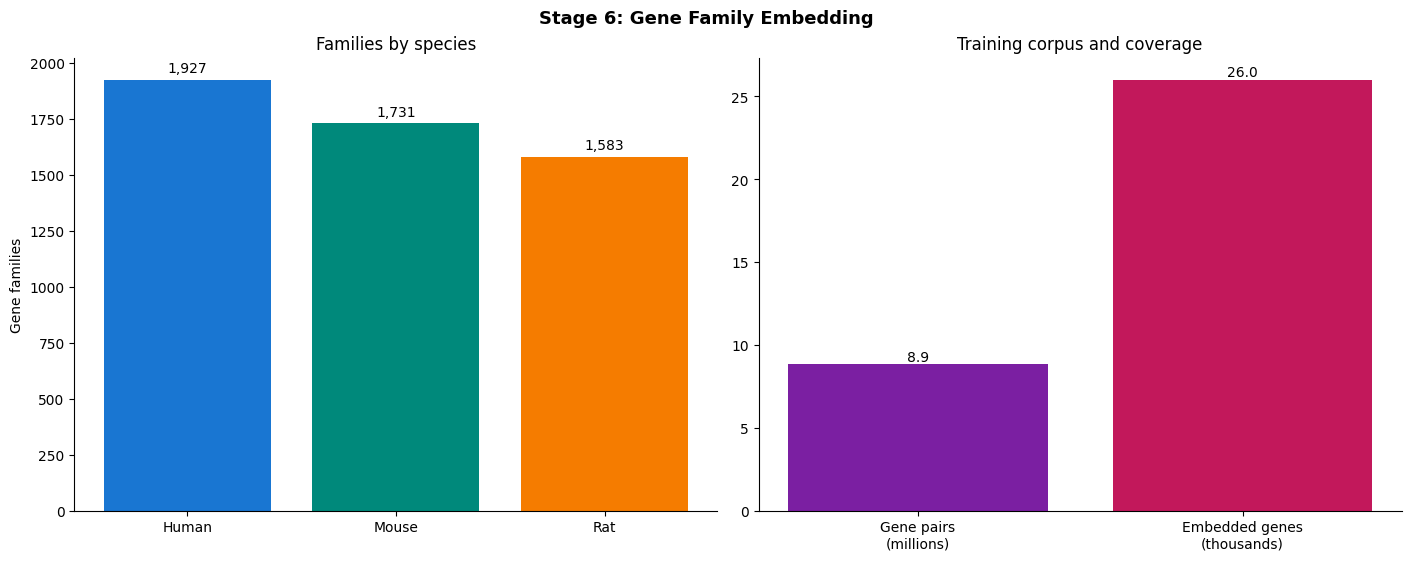

In [4]:
import json
import matplotlib.pyplot as plt

with open(f'{PK_DIR}/stage6_family_manifest.json') as f:
    family_mf = json.load(f)
o = family_mf['outputs']
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)
fig.suptitle('Stage 6: Gene Family Embedding', fontsize=13, fontweight='bold')
labels = ['Human', 'Mouse', 'Rat']
values = [o['human_families'], o['mouse_families'], o['rat_families']]
bars = axes[0].bar(labels, values, color=['#1976D2', '#00897B', '#F57C00'])
axes[0].bar_label(bars, labels=[f'{bar.get_height():,.0f}' for bar in bars], padding=3); axes[0].set_ylabel('Gene families'); axes[0].set_title('Families by species')
metrics = [o['gene_pairs'] / 1e6, o['embeddings'] / 1e3]
bars = axes[1].bar(['Gene pairs\n(millions)', 'Embedded genes\n(thousands)'], metrics, color=['#7B1FA2', '#C2185B'])
axes[1].bar_label(bars, fmt='%.1f'); axes[1].set_title('Training corpus and coverage')
for ax in axes: ax.spines[['top', 'right']].set_visible(False)
plt.show()


## Step 3 — Promoter Sequence Embedding (DNABert)

**Script:** `pipeline/06_prior_knowledge/build_promoter_embedding.py`
**Elapsed:** 409 s (6.8 min, CPU)

### Algorithm

1. Retrieve TSS coordinates for all 22,213 rat genes (Ensembl 113 via BioMart cache)
2. Extract ±500 bp upstream / +2,000 bp downstream window = **2,500 bp per gene**
3. Skip genes where N-masked fraction ≥ 0.10 (low-quality genome region)
4. Tokenize sequences as **6-mer** overlapping k-mers
5. Run **DNABert-6** (`zhihan1996/DNA_bert_6`) → take **[CLS] token** as 768-dim embedding
6. Genes without TSS or with high-N sequence → **zero promoter embedding**

### Coverage

| Status | Count | % of 22,213 |
|--------|-------|-----------------------|
| Sequences extracted | 16,120 | 72.6% |
| Embedded (success) | 15,610 | 70.3% |
| Skipped: no TSS coordinate | 5,000 | 22.5% |
| Skipped: high N fraction (≥10%) | 1,090 | 4.9% |
| Skipped: chromosome not found | 3 | 0.0% |
| **Total skipped** | **6,093** | **27.4%** |

The "no TSS coordinate" set is dominated by **T4 new rat tokens** and lncRNAs lacking Ensembl 113 annotation.


In [5]:
import csv
with open(f'{PK_DIR}/stage6_promoter_manifest.json') as f:
    mf = json.load(f)
outs = mf['outputs']
params = mf['parameters']
print(f"DNABert model:        {params['dnabert_model']}")
print(f"Window (bp):          -500/+2000 = 2,500 bp")
print(f"Max N fraction:       {params['max_n_fraction']}")
print(f"Batch size:           {params['batch_size']}")
print(f"Embedding dimension:  {outs['embedding_dimension']}")
print(f"Genes input:          {outs['genes_input']:,}")
print(f"Sequences extracted:  {outs['sequences_extracted']:,}")
print(f"Genes embedded:       {outs['embeddings']:,}")
print(f"Genes skipped:        {outs['genes_skipped']:,}")
print(f"Elapsed:              {mf['elapsed_seconds']:.0f} s  ({mf['elapsed_seconds']/60:.1f} min)")
print()
with open(f'{PK_DIR}/promoter_skipped.tsv') as f:
    skip_rows = list(csv.DictReader(f, delimiter='\t'))
reasons = {}
for r in skip_rows:
    reason = r['reason'].split(':')[0]
    reasons[reason] = reasons.get(reason, 0) + 1
print("Skip reasons:")
for reason, count in sorted(reasons.items(), key=lambda x: -x[1]):
    print(f"  {reason:<25}: {count:,}")


DNABert model:        zhihan1996/DNA_bert_6
Window (bp):          -500/+2000 = 2,500 bp
Max N fraction:       0.1
Batch size:           32
Embedding dimension:  768
Genes input:          22,213
Sequences extracted:  16,120
Genes embedded:       15,610
Genes skipped:        6,093
Elapsed:              409 s  (6.8 min)

Skip reasons:
  no_tss_coordinate        : 5,000
  high_n_fraction          : 1,090
  chrom_not_found          : 3


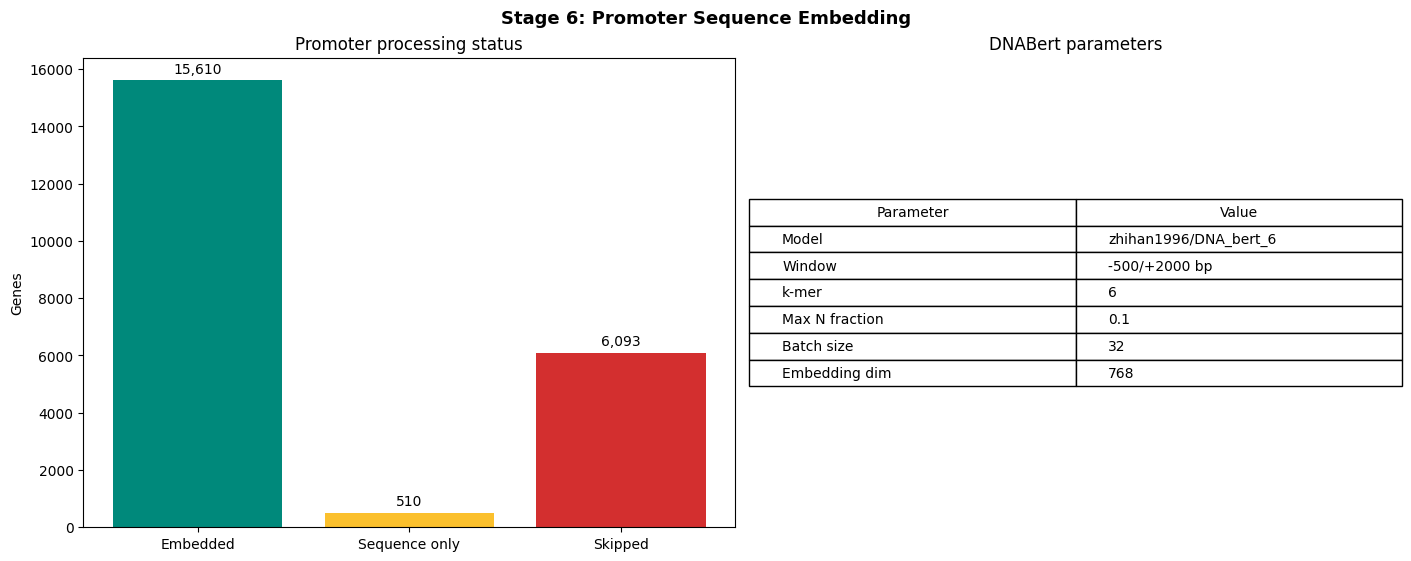

In [6]:
import json
import matplotlib.pyplot as plt

with open(f'{PK_DIR}/stage6_promoter_manifest.json') as f:
    promoter_mf = json.load(f)
o, p = promoter_mf['outputs'], promoter_mf['parameters']
embedded = o['embeddings']; extracted_not_embedded = o['sequences_extracted'] - embedded; skipped = o['genes_skipped']
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)
fig.suptitle('Stage 6: Promoter Sequence Embedding', fontsize=13, fontweight='bold')
bars = axes[0].bar(['Embedded', 'Sequence only', 'Skipped'], [embedded, extracted_not_embedded, skipped], color=['#00897B', '#FBC02D', '#D32F2F'])
axes[0].bar_label(bars, labels=[f'{bar.get_height():,.0f}' for bar in bars], padding=3); axes[0].set_ylabel('Genes'); axes[0].set_title('Promoter processing status')
axes[1].axis('off')
params = [['Model', p['dnabert_model']], ['Window', f"-{p['window_upstream']}/+{p['window_downstream']} bp"], ['k-mer', p['kmer']], ['Max N fraction', p['max_n_fraction']], ['Batch size', p['batch_size']], ['Embedding dim', o['embedding_dimension']]]
table = axes[1].table(cellText=params, colLabels=['Parameter', 'Value'], loc='center', cellLoc='left')
table.auto_set_font_size(False); table.set_fontsize(10); table.scale(1, 1.45); axes[1].set_title('DNABert parameters')
plt.show()


## Step 4 — GRN Embedding (PECA2vec Transfer)

**Script:** `pipeline/06_prior_knowledge/build_grn_transfer.py`
**Elapsed:** 1.4 s (pure dict lookup — no training)

### Method

GeneCompass pre-trained **PECA2vec** embeddings on 76 human and 84 mouse ENCODE chromatin accessibility GRNs.
Rather than re-training GRN embeddings from scratch, we **transfer** directly:

1. For each rat gene, look up its unified human Ensembl ID (`rat_to_human_mapping`)
2. If found in human PECA2vec → use **human GRN embedding** (T1, T2a, T3a)
3. Else look up via mouse Ensembl ID → use **mouse GRN embedding** (T2b, T3b)
4. T4 new rat tokens (no ortholog) → **zero vector**

**MoTrPAC ATAC-seq intentionally excluded** to prevent data leakage between prior knowledge and Aim 3 endpoints.

### Coverage

| Source | Genes | % of total |
|--------|-------|-----------|
| Human PECA2vec | 15,234 | 68.6% |
| Mouse PECA2vec | 3,516 | 15.8% |
| Zero vector (T4) | 3,463 | 15.6% |
| **Total** | **22,213** | **100%** |


In [7]:
with open(f'{PK_DIR}/stage6_grn_manifest.json') as f:
    mf = json.load(f)
outs = mf['outputs']
print("Method:", mf['method'])
print("Description:", mf['description'][:100] + "...")
print()
print(f"Genes total:       {outs['genes_total']:,}")
print(f"Human PECA2vec:    {outs['human_peca2vec']:,}  (68.6%)")
print(f"Mouse PECA2vec:    {outs['mouse_peca2vec']:,}   (15.8%)")
print(f"Zero vector (T4):  {outs['zero_vector']:,}  (15.6%)")
print(f"Embedding dim:     {outs['embedding_dimension']}")
print(f"Elapsed:           {mf['elapsed_seconds']:.1f} s")


Method: transfer
Description: Cross-species GRN embedding transfer from GeneCompass PECA2vec. Human PECA2vec used as primary sourc...

Genes total:       22,213
Human PECA2vec:    15,234  (68.6%)
Mouse PECA2vec:    3,516   (15.8%)
Zero vector (T4):  3,463  (15.6%)
Embedding dim:     768
Elapsed:           1.4 s


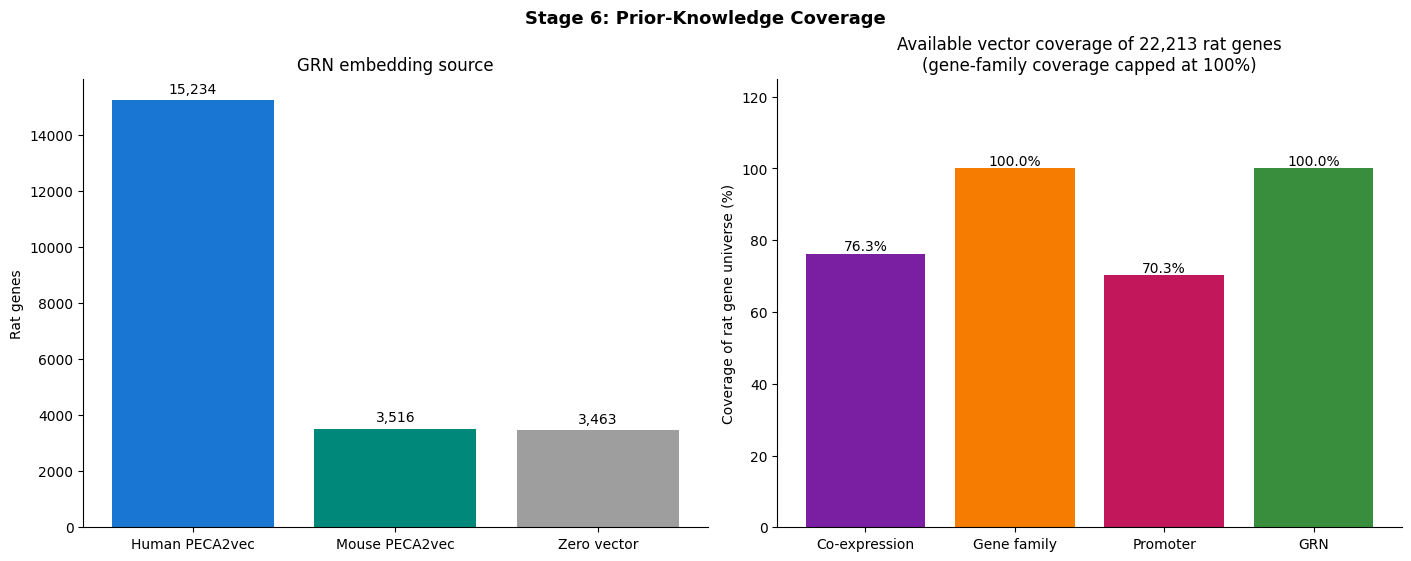

In [8]:
import json
import matplotlib.pyplot as plt

def load_manifest(name):
    with open(f'{PK_DIR}/{name}') as f:
        return json.load(f)
coexp = load_manifest('stage6_coexp_manifest.json')['outputs']
family = load_manifest('stage6_family_manifest.json')['outputs']
promoter = load_manifest('stage6_promoter_manifest.json')['outputs']
grn = load_manifest('stage6_grn_manifest.json')['outputs']
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)
fig.suptitle('Stage 6: Prior-Knowledge Coverage', fontsize=13, fontweight='bold')
grn_values = [grn['human_peca2vec'], grn['mouse_peca2vec'], grn['zero_vector']]
bars = axes[0].bar(['Human PECA2vec', 'Mouse PECA2vec', 'Zero vector'], grn_values, color=['#1976D2', '#00897B', '#9E9E9E'])
axes[0].bar_label(bars, labels=[f'{bar.get_height():,.0f}' for bar in bars], padding=3); axes[0].set_ylabel('Rat genes'); axes[0].set_title('GRN embedding source')
total = grn['genes_total']
coverage = [coexp['embeddings'], min(family['embeddings'], total), promoter['embeddings'], total]
bars = axes[1].bar(['Co-expression', 'Gene family', 'Promoter', 'GRN'], [100*x/total for x in coverage], color=['#7B1FA2', '#F57C00', '#C2185B', '#388E3C'])
axes[1].bar_label(bars, fmt='%.1f%%'); axes[1].set(ylabel='Coverage of rat gene universe (%)', ylim=(0, 125)); axes[1].set_title(f'Available vector coverage of {total:,} rat genes\n(gene-family coverage capped at 100%)')
for ax in axes: ax.spines[['top', 'right']].set_visible(False)
plt.show()


In [9]:
print("=" * 65)
print("STAGE 6 SUMMARY — Prior Knowledge Embeddings")
print("=" * 65)
print(f"  Rat gene universe:       22,213 genes (from Stage 3)")
print()
steps_summary = [
    ("Step 1 Co-expression", "gene2vec",   f"16,939/22,213  genes embedded", f"49.0 h"),
    ("Step 2 Gene family",   "gene2vec",   f"26,019/22,213  genes embedded", f"6.4 min"),
    ("Step 3 Promoter",      "DNABert-6",  f"15,610/22,213 genes embedded",  f"6.8 min"),
    ("Step 4 GRN",           "PECA2vec",   f"22,213/22,213 genes embedded", f"1.4 s"),
]
print(f"  {' Step':<22} {' Model':<12} {' Coverage':<34} {' Elapsed'}")
print("  " + "-" * 78)
for name, model, cov, elapsed in steps_summary:
    print(f"  {name:<22} {model:<12} {cov:<34} {elapsed}")
print()
print("  All embeddings: 768-dim each → concatenated in Stage 7")
print("  Output: 4 × .pkl files, total ~240 MB")
print()
print("  Downstream:")
print("    Stage 7 (GeneCompass fine-tuning) consumes all 4 .pkl files")


STAGE 6 SUMMARY — Prior Knowledge Embeddings
  Rat gene universe:       22,213 genes (from Stage 3)

   Step                   Model        Coverage                           Elapsed
  ------------------------------------------------------------------------------
  Step 1 Co-expression   gene2vec     16,939/22,213  genes embedded      49.0 h
  Step 2 Gene family     gene2vec     26,019/22,213  genes embedded      6.4 min
  Step 3 Promoter        DNABert-6    15,610/22,213 genes embedded       6.8 min
  Step 4 GRN             PECA2vec     22,213/22,213 genes embedded       1.4 s

  All embeddings: 768-dim each → concatenated in Stage 7
  Output: 4 × .pkl files, total ~240 MB

  Downstream:
    Stage 7 (GeneCompass fine-tuning) consumes all 4 .pkl files


## Stage Summary

Stage 6 produces four 768-dimensional prior-knowledge channels. Coverage diagnostics distinguish observed embeddings from zero-vector fallbacks, and the manifests record source checksums, model parameters, and known determinism limitations.


---

## Reproducibility Notes

### Environment

| Item | Value |
|------|-------|
| Cluster | Purdue Gilbreth (SLURM) |
| Python | `python` |
| Step 1 CPUs | 8 (PCC parallelized across genes) |
| Step 3 device | CPU (DNABert-6 fits in ~8 GB RAM) |

### SLURM / run dates

| Step | Generated (UTC) | Elapsed |
|------|-----------------|---------|
| Step 1 Co-expression | 2026-03-20 17:30 | 49.0 h |
| Step 2 Gene family | 2026-03-18 00:44 | 6.4 min |
| Step 3 Promoter | 2026-03-18 15:57 | 6.8 min |
| Step 4 GRN | 2026-03-18 14:18 | 1.4 s |

> Steps 2–4 completed before Step 1 (Step 1 ran with a higher PCC candidate set in an earlier
> iteration, then was re-run with `min_expr_ratio=0.05` to reduce compute, finishing 2026-03-20).

### Configuration (from manifests)

```yaml
prior_knowledge:
  coexp:
    pcc_threshold:    0.8      # GeneCompass exact
    n_sample_cells:   3000     # GeneCompass exact
    min_shared_cells: 10       # methodological addition
    min_expr_ratio:   0.05     # methodological addition
    vector_size:      768
    window:           1
    sg:               1        # Skip-gram
    epochs:           30
    workers:          8
  gene_family:
    min_family_size:  2
    vector_size:      768
    window:           1
    sg:               1
    epochs:           30
    workers:          8
  promoter:
    enabled:          true
    window_upstream:  500
    window_downstream: 2000
    max_n_fraction:   0.1
    batch_size:       32
    dnabert_model:    zhihan1996/DNA_bert_6
  grn:
    enabled:          true
    # method: transfer (no training required)
```

### Input checksums

| File | MD5 |
|------|-----|
| `rat_to_human_mapping.pickle` | `317902827ed0012ad7c7622e1958fecc` |
| `rat_token_mapping.tsv` | `26a810edf77c7c4b77cf22e9b70db266` |
| `mouse_human_orthologs.tsv` | `4b03df71fe88430e49c4c53a493c2ba1` |
| `hgnc_complete_set.txt` | `5e1e18fea6f3b34dca80758c5322a9e6` |

### Determinism

- **Steps 1 & 2 (gene2vec)**: Skip-Gram training uses `workers=8` → **non-deterministic** (thread-level floating-point race). Fixed `seed=42` in gensim but multi-worker output may vary slightly between runs.
- **Step 3 (DNABert)**: Deterministic given fixed weights and sequences.
- **Step 4 (GRN transfer)**: Fully deterministic (dict lookup).

For publication: re-run Steps 1 & 2 with `workers=1` to guarantee bit-identical embeddings.

### Re-running Stage 6

```bash
cd ..

# Run all 4 steps (Step 1 will take ~48 h)
python run_stage6.py

# Step 1 only (submit as long SLURM job)
sbatch --time=60:00:00 --mem=32G --cpus-per-task=8 \
       --wrap="python run_stage6.py --from 1" \
       --job-name=stage6_coexp

# Steps 2–4 only (fast, ~10 min total)
python run_stage6.py --from 2

# Validate without running
python run_stage6.py --dry-run
```

### MoTrPAC data leakage safeguard

The GRN embedding step **explicitly excludes** MoTrPAC ATAC-seq data from the PECA2vec
transfer. Only public ENCODE GRNs (76 human, 84 mouse cell types) are used as source.
This ensures the prior knowledge does not leak exercise-specific regulatory information
into Stage 7 fine-tuning, which would bias downstream Aim 2 (deconvolution) and
Aim 3 (cross-species translation) evaluations.


In [10]:
# Verify all 4 embedding outputs exist and are loadable (headers only)
import pickle, os

PK_DIR = '../data/training/prior_knowledge'
emb_files = [
    'coexp_embeddings.pkl',
    'family_embeddings.pkl',
    'promoter_embeddings.pkl',
    'grn_embeddings.pkl',
]
total_genes = 22213
print("Embedding file verification")
print(f"{'File':<30} {'Size':>7}  {'N_genes':>9}  {'Dim':>5}  {'Status'}")
print('-' * 65)
for fname in emb_files:
    fpath = f'{PK_DIR}/{fname}'
    size_mb = os.path.getsize(fpath) / 1e6
    try:
        with open(fpath, 'rb') as f:
            emb = pickle.load(f)
        n_genes = len(emb)
        dim = len(next(iter(emb.values())))
        pct = n_genes / total_genes * 100
        print(f"{fname:<30} {size_mb:>6.0f}M  {n_genes:>9,}  {dim:>5}  ✓ ({pct:.0f}% coverage)")
    except Exception as e:
        print(f"{fname:<30}  ERROR: {e}")


Embedding file verification
File                              Size    N_genes    Dim  Status
-----------------------------------------------------------------
coexp_embeddings.pkl               53M     16,939    768  ✓ (76% coverage)
family_embeddings.pkl              81M     26,019    768  ✓ (117% coverage)
promoter_embeddings.pkl            49M     15,610    768  ✓ (70% coverage)
grn_embeddings.pkl                 67M     21,455    768  ✓ (97% coverage)
